In [4]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

<IPython.core.display.Javascript object>

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import wandb
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import torchvision

import sys
sys.path.append('../src/')
from hierarchy_functions import *

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter1 = list_to_dict(symmetry_classes)

label_converter2 = {0:'no rotation', 1:'2-fold rot', 2:'3-fold rot'}

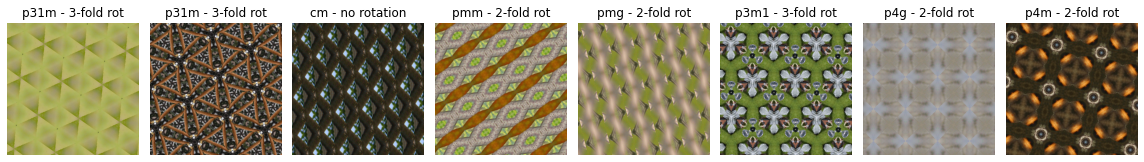

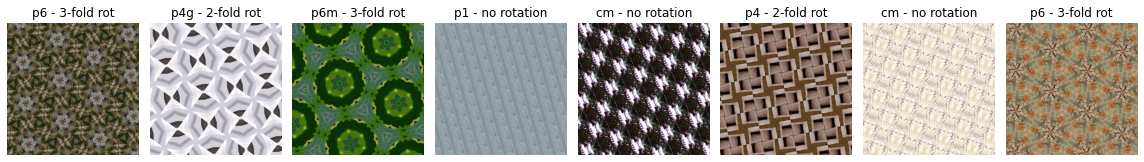

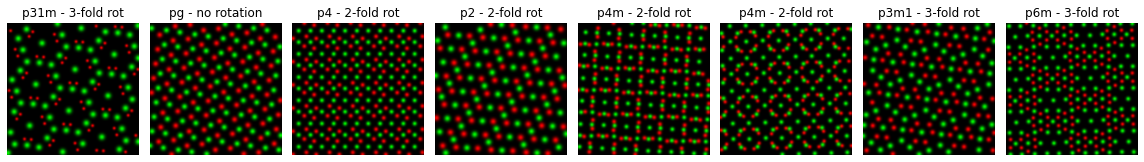

CPU times: user 20.3 s, sys: 1.25 s, total: 21.6 s
Wall time: 8.75 s


In [3]:
%%time
# imagenet
train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_hierarchy.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=230, shuffle=True, num_workers=6)
viz_dataloader(train_dl, label_converter1=label_converter1, label_converter2=label_converter2)

valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_hierarchy.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=230, shuffle=True, num_workers=6)
viz_dataloader(valid_dl, label_converter1=label_converter1, label_converter2=label_converter2)

test_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_hierarchy.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=1024, shuffle=True, num_workers=6)
viz_dataloader(test_dl, label_converter1=label_converter1, label_converter2=label_converter2)

In [4]:
model = models.resnet50()

model.fc = nn.Sequential(nn.BatchNorm1d(2048),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 2048, out_features=512, bias=False),
                         nn.ReLU(inplace=True),

                         nn.BatchNorm1d(512),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 512, out_features=64, bias=False),
                         nn.ReLU(inplace=True),
                         
                         nn.BatchNorm1d(64),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features=64, out_features=17, bias=True)
                        )
model(torch.randn(2,3,256,256)).shape

torch.Size([2, 17])

torch.Size([2, 17])

In [5]:
config = {
    'dataset': '/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_hierarchy.h5',
    'device': torch.device('cuda:1'),
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
    'dropout': 0.5
}

NAME = '10152023-hierarchy-resnet50_from_scratch-v4_2m_5percent_subset'

# train

In [20]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

<IPython.core.display.Javascript object>

In [22]:
# os.environ["WANDB_NOTEBOOK_NAME"] = nb_name
wandb.init(project='symmetry_paper', entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [23]:
device = config['device']
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models_new/', tracking=True)

Epoch: 1/50


100%|██████████| 435/435 [02:33<00:00,  2.83it/s]


Training: Loss: 2.9395, Accuracy: 9.9470%, Time: 2.5607mins


100%|██████████| 435/435 [01:06<00:00,  6.50it/s]


Validation : Loss : 2.7079, Accuracy: 30.9520%, Time: 1.12mins


...

Training: Loss: 0.0014, Accuracy: 99.9650%, Time: 2.4932mins


100%|██████████| 435/435 [01:12<00:00,  5.98it/s]


Validation : Loss : 0.2271, Accuracy: 96.1560%, Time: 1.21mins


100%|██████████| 98/98 [01:07<00:00,  1.45it/s]


Validation : Loss : 5.3885, Accuracy: 48.4750%, Time: 1.13mins


In [24]:
device = config['device']
lr = 1e-3
start = 50
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models_new/', tracking=True)

Epoch: 51/100


  6%|▌         | 24/435 [00:09<02:23,  2.87it/s]

# analyze

In [6]:
model = torch.load('/scratch/yichen/models_new/10152023-hierarchy-resnet50_from_scratch-v4_2m_5percent_subset-epoch-100.pt')

In [2]:
NAME = '10152023-hierarchy-resnet50_from_scratch-v4_2m_5percent_subset'

In [3]:
from hierarchy_functions import confusion_matrix, plot_cm

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter1 = list_to_dict(symmetry_classes)
label_converter2 = {0:'no rotation', 1:'2-fold rot', 2:'3-fold rot'}

symmetry_classes_l1 = ['no rotation', '2-fold rot', '3-fold rot']

In [8]:
device = torch.device('cuda:0')

cm = confusion_matrix(model, train_dl, symmetry_classes_l1, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

  0%|          | 0/435 [00:00<?, ?it/s]

100%|██████████| 435/435 [02:36<00:00,  2.77it/s]

Sum for true labels:


,no rotation,2-fold rot,3-fold rot
0,23583.0,47013.0,29404.0


Accuracy for these batches: 0.99985


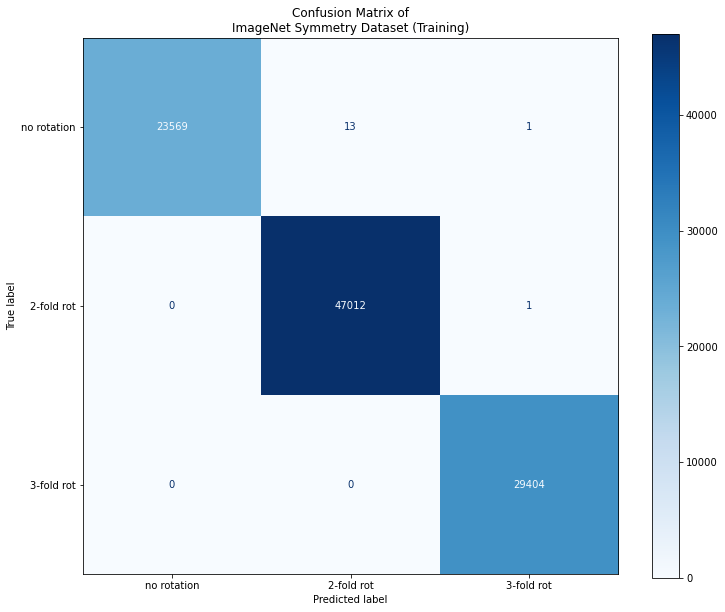

In [9]:
cm = np.load(NAME+'-train_cm.npy')

# plot_cm(cm, symmetry_classes_l1, save_file=NAME+'-train_cm-with_axis.svg', title='\nImageNet Symmetry Dataset (Training)', style='with_axis')
plot_cm(cm, symmetry_classes_l1, save_file=NAME+'-train_cm-simple.svg', title='\nImageNet Symmetry Dataset (Training)', style='simple')

In [10]:
cm = confusion_matrix(model, valid_dl, symmetry_classes_l1, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

  0%|          | 0/435 [00:00<?, ?it/s]

100%|██████████| 435/435 [02:20<00:00,  3.09it/s]

Sum for true labels:


,no rotation,2-fold rot,3-fold rot
0,23326.0,47296.0,29378.0


Accuracy for these batches: 0.9618


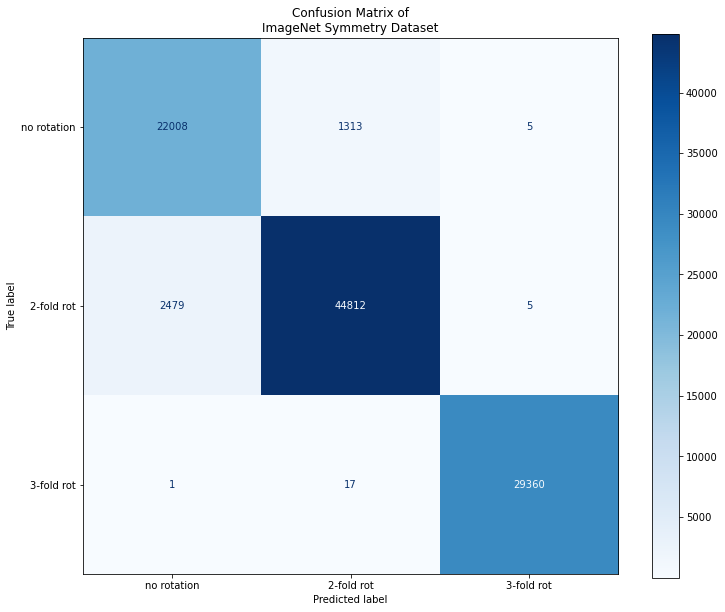

In [11]:
# cm = np.load(NAME+'-valid_cm.npy')

plot_cm(cm, symmetry_classes_l1, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [12]:
cm = confusion_matrix(model, test_dl, symmetry_classes_l1, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

  0%|          | 0/98 [00:00<?, ?it/s]

100%|██████████| 98/98 [03:36<00:00,  2.21s/it]

Sum for true labels:


,no rotation,2-fold rot,3-fold rot
0,23523.0,47059.0,29418.0


Accuracy for these batches: 0.48704


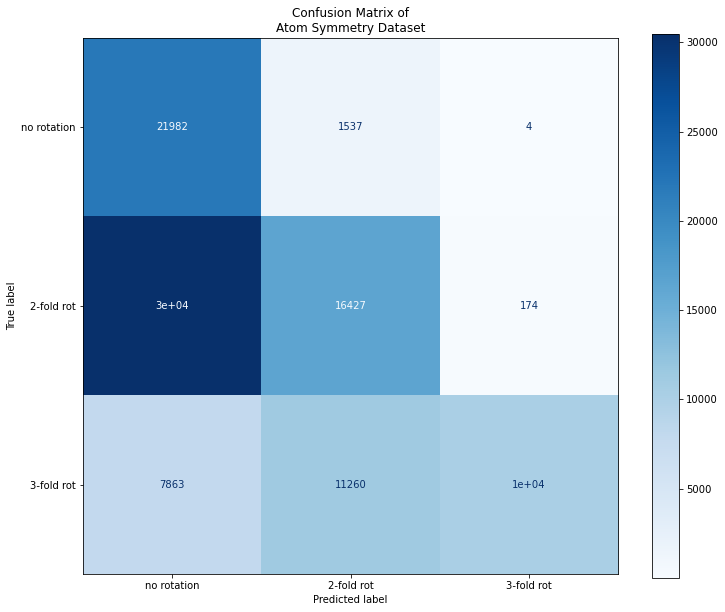

In [13]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes_l1, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
import sys
sys.path.append('../../../helper_functions/')
from python_email import send_email
send_email()

In [ ]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)
restartkernel()